In [69]:
import numpy as np
import matplotlib.pyplot as plt

# Train Dataset

## Data

In [70]:
data = np.load("/kaggle/input/waveform-inversion/train_samples/Style_A/data/data1.npy")
print(data.shape)
x = data[0]  # first sample
print(x.shape)

(500, 5, 1000, 70)
(5, 1000, 70)


* 500 -> number of samples
* 5 -> number of seismic sources per sameple
* 1000 -> time steps recorded
* 70 -> number of recievers

One seismic sample with shape:
```
(5, 1000, 70)
sources × time × receivers
```

### 1. Slice by source

This plot shows 2D seismic shot gathers for a single training sample, visualized separately for each of the 5 seismic sources.

For each source, the seismic data is displayed as a time × receiver image, where:

* X-axis represents receiver index (spatial location of receivers)
* Y-axis represents time steps (wave propagation over time)
* Color intensity represents seismic wave amplitude

The bright, slanted/curved patterns correspond to wave arrivals and reflections, indicating how seismic energy propagates through the subsurface.
Differences across sources reflect different source positions illuminating the same underground structure from different angles.

This visualization is the primary and most informative representation of seismic input used by CNN-based inversion models.

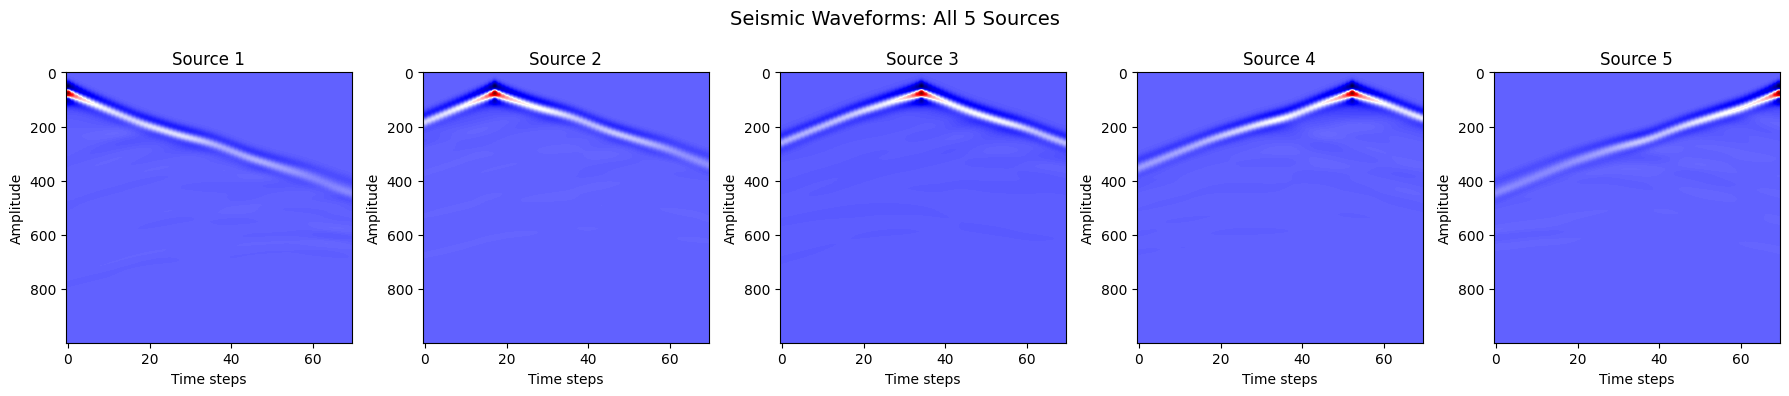

In [71]:
plt.figure(figsize=(18, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x[i], aspect="auto", cmap="seismic")
    plt.title(f"Source {i + 1}")
    plt.xlabel("Time steps")
    plt.ylabel("Amplitude")

plt.suptitle("Seismic Waveforms: All 5 Sources", fontsize=14)
plt.tight_layout()
plt.show()

### 2. Slice by receiver

This plot shows seismic waveforms recorded at a single receiver location, visualized over time for all 5 seismic sources.

* X-axis represents time steps
* Y-axis represents wave amplitude
* Each colored curve corresponds to a different seismic source

Differences in arrival time and amplitude across sources reflect different source positions illuminating the same receiver.

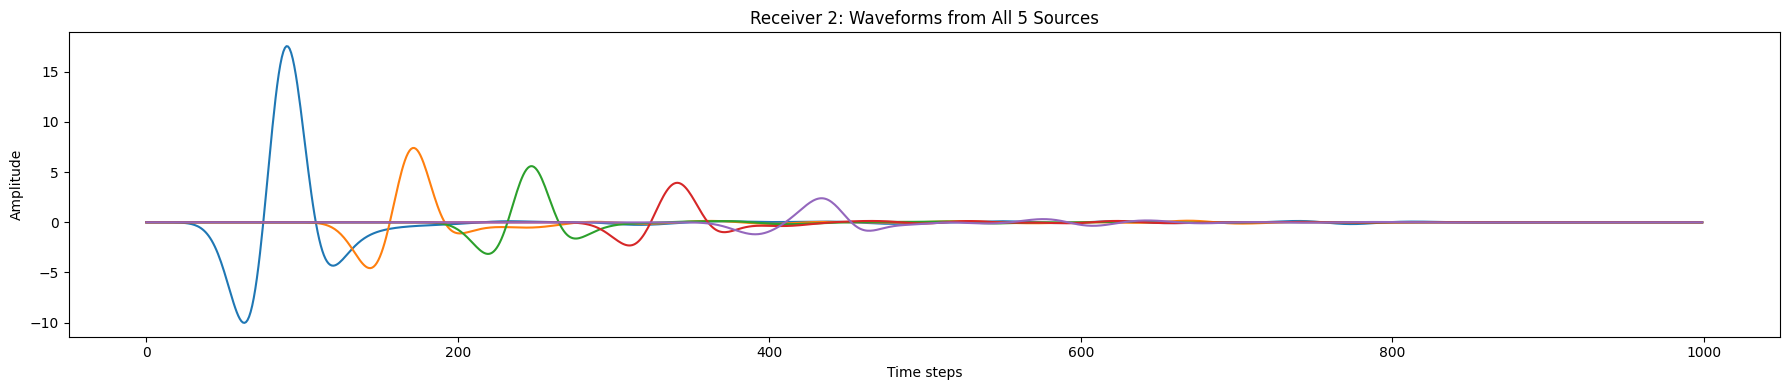

In [72]:
receiver_number = 2  # choose receiver index

plt.figure(figsize=(18, 4))

# x[:, :, receiver_number] -> (5,1000).T -> (1000,5)
# X-axis → time
# Each line → one source
plt.plot(x[:, :, receiver_number].T)

plt.xlabel("Time steps")
plt.ylabel("Amplitude")
plt.title(f"Receiver {receiver_number}: Waveforms from All 5 Sources")

plt.tight_layout()
plt.show()

### 3. Slice by time

This plot shows a wavefield snapshot of the seismic data at a fixed time step (t = 300) for a single training sample.

At this specific moment in time:

* X-axis represents the receiver index (spatial positions of receivers)
* Y-axis represents the seismic source index
* Color intensity represents the seismic wave amplitude

Each row corresponds to the wave energy recorded from one seismic source across all receivers at the same time step.
Bright regions indicate strong wave arrivals at particular receivers, while darker regions indicate low or no wave energy.

This visualization provides an instantaneous spatial view of how seismic energy from different sources propagates through the subsurface and reaches the receiver array.

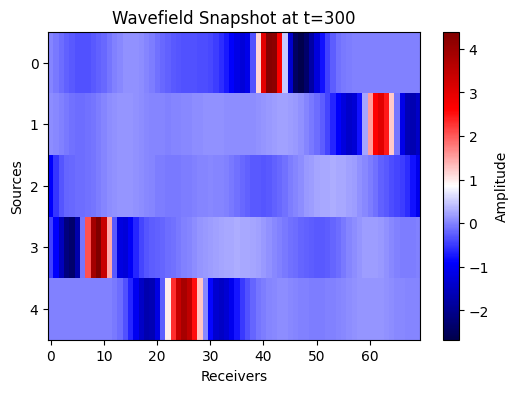

In [73]:
time_id = 300  # try early vs late times

plt.figure(figsize=(6, 4))
plt.imshow(x[:, time_id, :], aspect="auto", cmap="seismic")
plt.colorbar(label="Amplitude")
plt.xlabel("Receivers")
plt.ylabel("Sources")
plt.title(f"Wavefield Snapshot at t={time_id}")
plt.show()

## Model

In [74]:
model = np.load(
    "/kaggle/input/waveform-inversion/train_samples/Style_A/model/model1.npy"
)
print(model.shape)

(500, 1, 70, 70)


This plot shows the ground-truth subsurface velocity map for a single training sample from the dataset.

The velocity map is a 2D spatial image where:

* Each pixel represents the seismic wave velocity at a specific subsurface location
* Color intensity (shown by the colorbar) indicates the magnitude of velocity, with lower velocities shown in darker colors and higher velocities in brighter colors

The smooth spatial variations and localized high-velocity regions reflect different subsurface material properties and structural patterns present in the model.

This velocity map serves as the supervised learning target for the model, which must learn to predict this image from the corresponding seismic waveform data.

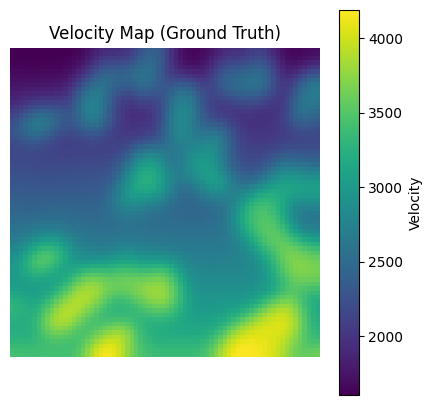

In [75]:
plt.figure(figsize=(5, 5))
plt.imshow(model[0][0], cmap="viridis")
plt.colorbar(label="Velocity")
plt.title("Velocity Map (Ground Truth)")
plt.axis("off")
plt.show()